In [18]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join as pjoin
from matplotlib.ticker import MaxNLocator
import pandas as pd

from utils import OperonArgs

from matplotlib import rcParams
rcParams['font.size'] = 12
rcParams['figure.dpi'] = 150
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 14
rcParams['legend.fontsize'] = 12
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12

# Pareto Fronts

conf: conf/iob_35.ini, ilen: 13

Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini
conf: conf/iob_44.ini, ilen: 43

Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini


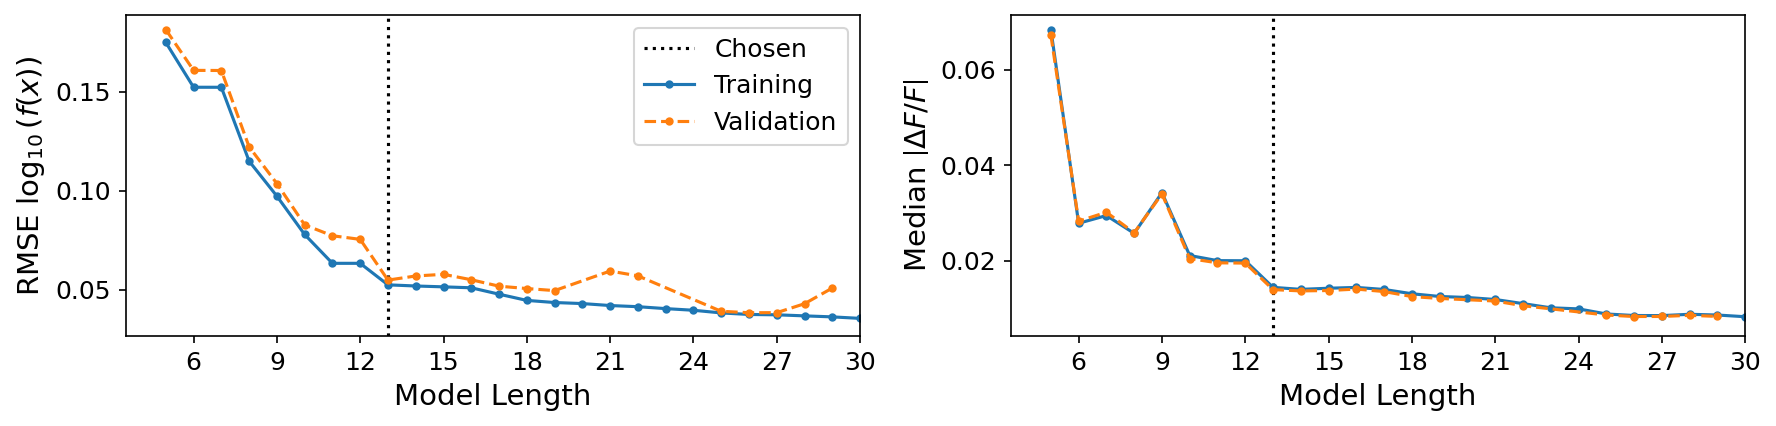

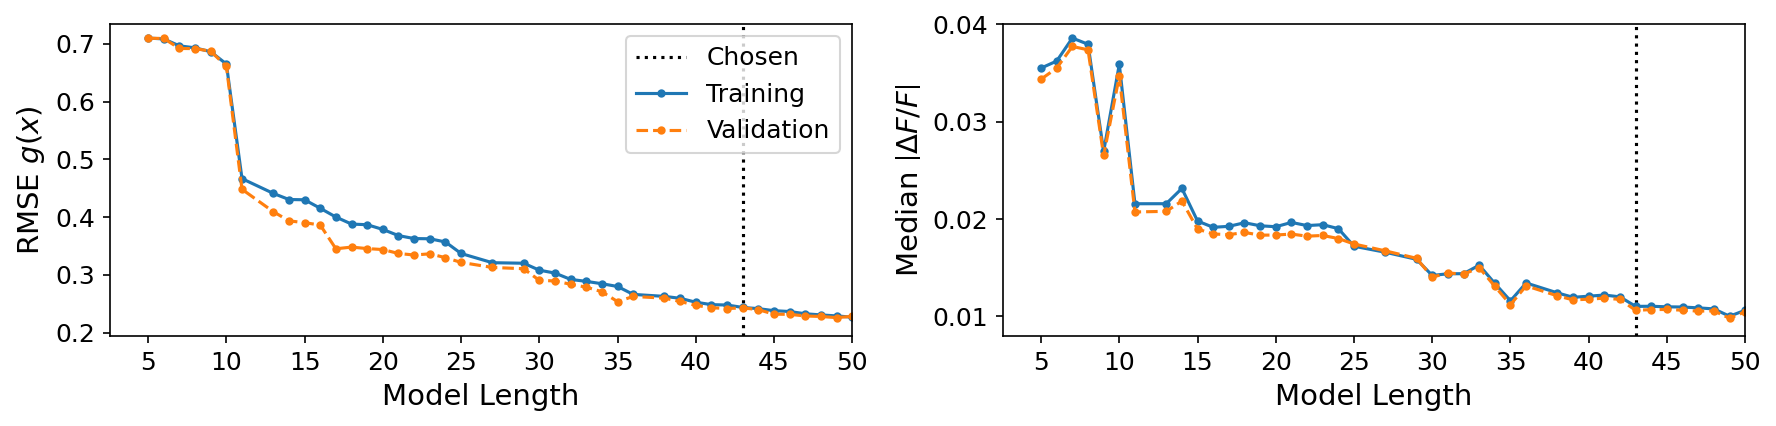

In [ ]:
all_run = [
    ('conf/iob_35.ini', 13, r'$\log_{10} (f(x))$'),
    ('conf/iob_44.ini', 43, r'$g(x)$'),
]

# cmap = plt.get_cmap('Set1')
cmap = plt.get_cmap('tab10')
fig_dir = 'figs/'

for ini_file, ilen, label in all_run:
    print(f'conf: {ini_file}, ilen: {ilen}')

    args = OperonArgs(ini_file)
    
    run_name = f'{args.in_param}_{str(args.version_num)}'
    out_dir = pjoin(args.fit_dir, run_name)
    fname = f'{out_dir}/{run_name}_fun.csv'
    df = pd.read_csv(fname, delimiter=';')
    eq_idx = list(df['Length']).index(ilen)
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharex=True)

    axs[0].axvline(df['Length'].to_numpy()[eq_idx], ls=':', color='k', label='Chosen')
    m = np.isfinite(np.sqrt(df['MSE_train']))
    x = np.array(df['Length'][m])
    y = np.array(np.sqrt(df['MSE_train'])[m])
    i = np.argsort(x)
    axs[0].plot(x[i], y[i], marker='.', color=cmap(0), label='Training')
    m = np.isfinite(np.sqrt(df['MSE_val']))
    x = np.array(df['Length'][m])
    y = np.array(np.sqrt(df['MSE_val'])[m])
    i = np.argsort(x)
    axs[0].plot(x[i], y[i], marker='.', ls='--', color=cmap(1), label='Validation')
    if axs[0].get_xlim()[1] > args.max_length:
        axs[0].set_xlim(None, args.max_length)
    axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[0].set_ylabel('RMSE ' + label)

    axs[1].axvline(df['Length'].to_numpy()[eq_idx], ls=':', color='k', label='Chosen')
    m = np.isfinite(df['MedAE_train_F'])
    x = np.array(df['Length'][m])
    y = np.array(df['MedAE_train_F'][m])
    i = np.argsort(x)
    axs[1].plot(x[i], y[i], marker='.', color=cmap(0), label='Training')
    m = np.isfinite(df['MedAE_val_F'])
    x = np.array(df['Length'][m])
    y = np.array(df['MedAE_val_F'])[m]
    i = np.argsort(x)
    axs[1].plot(x[i], y[i], marker='.', ls='--', color=cmap(1), label='Validation')
    if axs[1].get_xlim()[1] > args.max_length:
        axs[1].set_xlim(None, args.max_length)
    axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[1].set_ylabel('Median ' + r'$\left| \Delta F / F \right|$')

    for ax in axs:
        ax.set_ylim(max(0, ax.get_ylim()[0]), None)
        ax.set_xlabel('Model Length')
        ax.legend(loc='upper right')
    
    fig.align_labels()
    fig.tight_layout()

    fig.savefig(pjoin(fig_dir, f'{run_name}_results.pdf'), bbox_inches='tight')